In [30]:
from tensorflow.keras.preprocessing.image import  ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.layers import Input 
from tensorflow.keras.models import Model 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths 
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf 

In [20]:
 # Initialize the initial learning rate , number of epochs to train for, 
 # And batch size
 INIT_LR = 1e-4
 EPOCHS = 2
 BS = 32
 DIRECTORY = "dataset"

In [21]:
data = []
labels = []

for category in os.listdir(DIRECTORY):
    path = os.path.join(DIRECTORY, category)
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        image = load_img(img_path, target_size=(224, 224))
        image = img_to_array(image)
        image = preprocess_input(image)

        data.append(image)
        labels.append(category)
print(labels[:10])

['without_mask', 'without_mask', 'without_mask', 'without_mask', 'without_mask', 'without_mask', 'without_mask', 'without_mask', 'without_mask', 'without_mask']


In [22]:
# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)

data = np.array(data , dtype = "float32")
labels = np.array(labels)

In [23]:
labels[-10:]


array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [24]:
labels[:10]

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [32]:
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.20, stratify=labels, random_state=42)

In [26]:
# Construct the training image generate for data augmentation
aug = ImageDataGenerator(
    rotation_range = 20,
    zoom_range = 0.15,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.15,
    horizontal_flip = True,
    fill_mode = "nearest")

In [27]:
# Load the MobileNetV2 network, ensuring the head FC Layer sets are
# Left off
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224,224,3)))

C:\Users\AMAN SHANKAR\AppData\Local\Temp\ipykernel_29184\401305730.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224,224,3)))


In [28]:
# Construct the head of  the model that will be placed on the top of the base model
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7,7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2 , activation="softmax")(headModel)

# Place the Head FC model on top of the base model (this will become the actual model we will train)
model = Model(inputs = baseModel.input , outputs = headModel)

# Loop over all the layers in the base model and freeze them so they will *not* be updated during first training process
for layer in baseModel.layers:
    layer.trainable = False

In [31]:
# Complete our model 
print("[INFO] completing model....")
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
# opt = Adam(lr =INIT_LR, decay =INIT_LR / EPOCHS)
# model.complete(loss = "binary_crossentropy" , optimizer=opt , metrics=['accuracy'])

[INFO] completing model....


In [34]:
# train the head of the network
print("[INFO] training head...")
H = model.fit(
    aug.flow(trainX , trainY , batch_size=BS),
    steps_per_epoch=len(trainX) // BS,
    validation_data=(testX, testY),
    validation_steps=len(testX) // BS,
    epochs=EPOCHS)

[INFO] training head...
Epoch 1/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.3750 - loss: 0.9733 - val_accuracy: 0.4000 - val_loss: 0.8570
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4688 - loss: 1.2460 - val_accuracy: 0.4000 - val_loss: 0.8379


In [35]:
# make predictions on the testing set
print("[INFO] evaluating network.....")
predIdxs = model.predict(testX , batch_size=BS)

[INFO] evaluating network.....
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step


In [36]:
# For each image in the testing set we need to find the index of the label with largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)

# Show a nocely formatted classification report
print(classification_report(testY.argmax(axis=1) , predIdxs , target_names=lb.classes_))

              precision    recall  f1-score   support

   with_mask       0.40      0.40      0.40         5
without_mask       0.40      0.40      0.40         5

    accuracy                           0.40        10
   macro avg       0.40      0.40      0.40        10
weighted avg       0.40      0.40      0.40        10



In [39]:
# Resize the model to disk 
print("[INFO] saving mask detector model...")
model.save("mask_detector.model.h5")

[INFO] saving mask detector model...


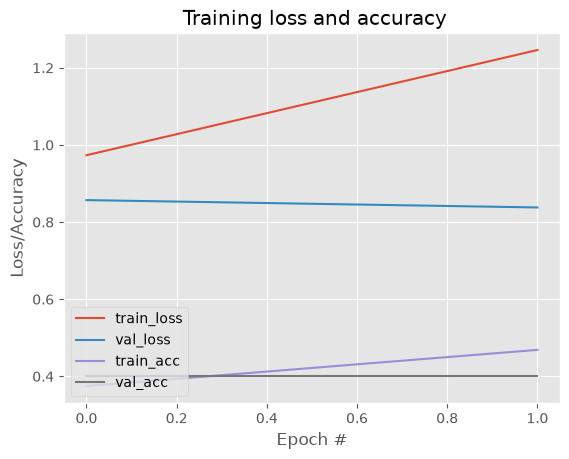

In [41]:
# Plot the traing loss and accuracy

N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label = "train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label= "val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label= "train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label= "val_acc")
plt.title(" Training loss and accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig("plt.png")